# Residual_Diagnostics


## 01. Import


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge  # Regularized linear regression model used for residual diagnostics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 2. Load Processed Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load the processed modeling dataset

df.head() # Preview the first five rows to confirm the dataset loaded correctly


,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and predictors

In [ ]:
target = "monthly_cost" # Define the regression target variable

drop_cols = [
    "member_id",  # Identifier, not a predictive feature
    target,  # Target variable must be removed from predictors
    "high_cost_member",  # Derived from monthly_cost, so this leaks target information
    "awv_completed"  # Exclude AWV outcome to keep cost prediction focused on risk, access, and utilization
]

X = df.drop(columns=drop_cols, errors="ignore")  # Create predictors after removing leakage-prone columns
y = df[target]  # Store monthly cost as the regression target

## 4. Train-test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)  # Split the data into training and testing sets, using 80% of the data for training and 20% for testing. Set a random state for reproducibility.


## 5. Identify numeric and categorical columns

In [5]:
numeric_cols = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]  # Select numeric predictors
).columns.tolist()  # Store numeric column names as a list

categorical_cols = X_train.select_dtypes(
    include=["object", "string", "category", "bool"]  # Select categorical/text-like predictors
).columns.tolist()  # Store categorical column names as a list
numeric_cols, categorical_cols # Print the numeric and categorical columns to confirm they were identified correctly

(['age',
  'sdoh_risk_score',
  'chronic_condition_count',
  'engagement_score',
  'pcp_attributed_24mo',
  'prior_awv_count',
  'prior_awv_rate',
  'ed_visits',
  'ip_admits',
  'prior_awv_group',
  'total_acute_visits',
  'has_acute_utilization'],
 ['gender',
  'region',
  'plan_type',
  'engagement_group',
  'age_group',
  'chronic_burden_group',
  'sdoh_risk_group',
  'acute_utilization_group',
  'pcp_status'])

## 6. Build preprocessing

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),  # Standardize numeric columns
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)  # One-hot encode categorical columns
    ]
)


## 7. Rebuild tuned ridge model

In [7]:
ridge_pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Apply scaling and one-hot encoding before modeling
        ("model", Ridge()) # Fit Ridge regression after preprocessing
    ]
)

ridge_param_grid = {
    "model__alpha": [0.001,0.01, 0.1, 1.0, 10.0, 100.0] # Candidate Ridge penalty strengths 
}

ridge_grid = GridSearchCV(
    ridge_pipeline, # Pipeline that includes preprocessing and Ridge model
    ridge_param_grid, # Alpha values to test
    cv=5, # Use 5-fold cross validation
    scoring = "neg_root_mean_squared_error" # Choose alpha based on RMSE performance
)

ridge_grid.fit(X_train, y_train) # Fit Ridge models across alpha values using cross validation

best_ridge = ridge_grid.best_estimator_ # Save the best Ridge pipeline selected by cross validation

ridge_grid.best_params_ # Display the best alpha value




{'model__alpha': 10.0}

## 8. Generate predictions and residuals

In [8]:
y_pred = best_ridge.predict(X_test) # Generate predictions on the test set using the best Ridge model
residuals = y_test - y_pred # Calculate residuals as the difference between actual and predicted values

results_df = pd.DataFrame({
    "actual" : y_test, # True monthly cost values
    "predicted" : y_pred, # Model-predicted monthly cost values
    "residual" : residuals, # Difference between actual and predicted values
    "absolute_error" : np.abs(residuals) # Error size regardless of direction
})

results_df.head() # Preview prediction results and residuals



,actual,predicted,residual,absolute_error
1801,2257.67,2197.270065,60.399935,60.399935
1190,1989.07,1892.952073,96.117927,96.117927
1817,859.61,965.358091,-105.748091,105.748091
251,2748.64,2789.650952,-41.010952,41.010952
2505,2059.28,1937.279720,122.000280,122.000280


## 9. Evaluate model performance again

In [9]:
mae = mean_absolute_error(y_test, y_pred) # Average absolute prediction error
rmse = mean_squared_error(y_test, y_pred) ** 0.5 # Root mean squared error, more sensitive to large error
r2 = r2_score(y_test, y_pred) # Percent of target variance explained by the model

print("MAE:", mae) # Print average average absolute error (average miss size)
print("RMSE", rmse)  # Print root mean squared error (large errors-sensitive miss size)
print("R^2:", r2) # Print R-squared value (variance explained)
print("Mean Residual:", residuals.mean()) # Check average prediction bias (mean residual > 0 = model tends to underpredict)
print("Median residuals:", residuals.median()) # Check typical residual direction (mean residual < 0 = model  tends to overpredict)

# RMSE much larger than MAE = large errors or outliers exist

MAE: 363.0722483869238
RMSE 634.6606295157032
R^2: 0.7777945857907294
Mean Residual: 12.356904905191087
Median residuals: -69.9345905586988


## 10. Actual vs predicted plot

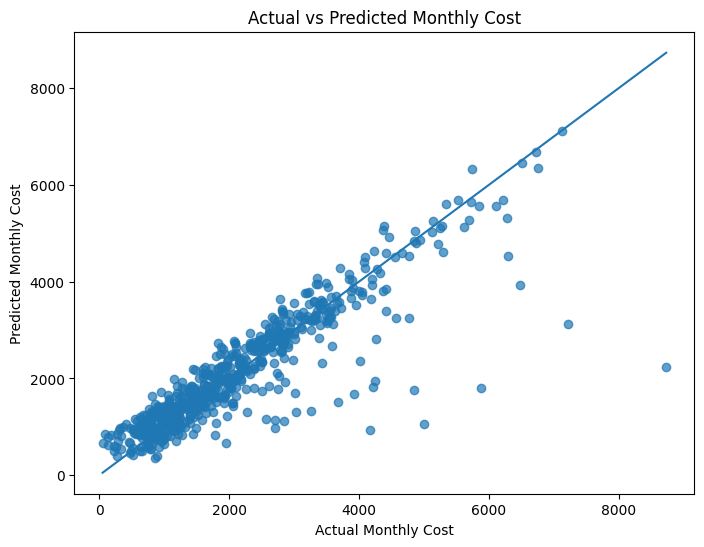

In [10]:
plt.figure(figsize = (8,6))  # Set plot size

plt.scatter(
    results_df["actual"], #x-axis: true monthly cost
    results_df["predicted"], #Y-axis: predicted monthly cost
    alpha = 0.7 # Make points slightly transparent 
)

plt.xlabel("Actual Monthly Cost") # Label x-axis
plt.ylabel("Predicted Monthly Cost") # Label y-axis
plt.title("Actual vs Predicted Monthly Cost") # Add plot title

min_val = min(results_df["actual"].min(), results_df["predicted"].min()) #Get lower bound for diagonal reference line
max_val = max(results_df["actual"].max(), results_df["predicted"].max()) #Get upper bound for diagonal reference line

plt.plot([min_val, max_val], [min_val, max_val])

plt.show() #Display the plot



## 11. Residuals vs predicted values plot 

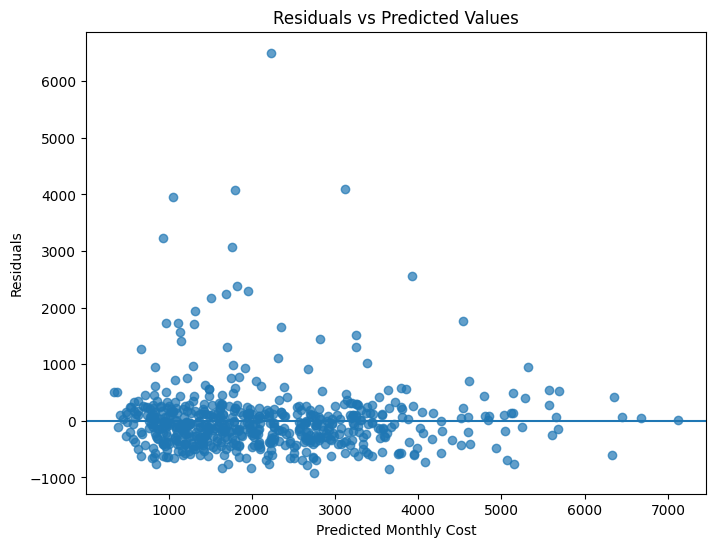

In [11]:
plt.figure(figsize = (8,6)) # Set plot size

plt.scatter(
    results_df["predicted"], # x-axis: predicted monthly cost
    results_df["residual"], # y-axis: residuals
    alpha = 0.7 # Make points slightly transparent
)

plt.axhline(y=0) # Add horizontal reference line at zero residual
plt.xlabel("Predicted Monthly Cost") # label x-axis
plt.ylabel("Residuals") # Label y-axis
plt.title("Residuals vs Predicted Values") # Add plot title

plt.show()



## 12. Residual distribution plot

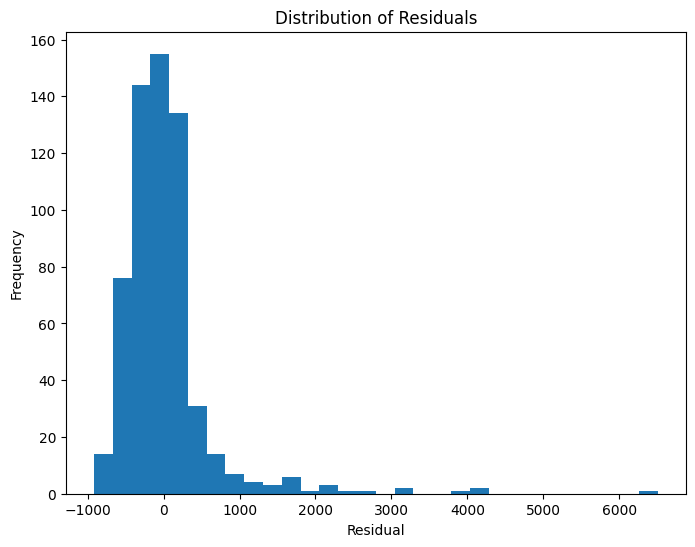

In [12]:
plt.figure(figsize = (8,6)) # Set plot size

plt.hist(
    results_df["residual"], # Plot distribution of residuals
    bins = 30 # Use 30 bars for the histogram
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals") # Add plot title

plt.show() 


## 13. Inspect largest errors

In [13]:
largest_errors = results_df.sort_values(
    "absolute_error", #Sort by error size
    ascending = False # Put biggest errors first
)

largest_errors.head(10)


    

,actual,predicted,residual,absolute_error
1336,8734.22,2228.730903,6505.489097,6505.489097
124,7218.17,3118.700689,4099.469311,4099.469311
1706,5879.72,1795.011322,4084.708678,4084.708678
408,5004.13,1050.775825,3953.354175,3953.354175
457,4163.09,930.974290,3232.115710,3232.115710
685,4841.47,1764.219432,3077.250568,3077.250568
1429,6484.28,3922.214485,2562.065515,2562.065515
1618,4215.42,1826.350242,2389.069758,2389.069758
1231,4247.30,1955.212831,2292.087169,2292.087169
0,3920.62,1686.101862,2234.518138,2234.518138


## 14. Add error bands

In [14]:
results_df["error_band"] = pd.cut(
    results_df["absolute_error"], # Group members based on absolute error size
    bins = [0, 100, 250, 500, 1000, np.inf], # Define error ranges
    labels = ["0-100", "100-250", "250-500", "500-1000", "1000+"] # Name each error range
)
results_df["error_band"].value_counts().sort_index() # Count how many members fall into each error band

error_band
0-100       120
100-250     186
250-500     177
500-1000     91
1000+        26
Name: count, dtype: int64

## 15. Compare residuals by actual cost group

In [15]:
results_df["actual_cost_group"] = pd.qcut(
    results_df["actual"], # Split members based on actual monthly cost
    q=4, # Create four groups: Lowest to highest cost quartiles
    labels = ["Low", "Medium-Low", "Medium-High", "High"] # Label each quartile
)

results_df.groupby("actual_cost_group")["absolute_error"].mean() # Calculate average error by actual cost group

cost_group_summary = results_df.groupby("actual_cost_group").agg(
    avg_actual_cost = ("actual", "mean"), # Average actual cost within each group
    avg_predicted_cost =  ("predicted", "mean"), # Average predicted cost within each group
    avg_residual = ("residual", "mean"),  # Average underprediction or overprediction
    avg_absolute_error = ("absolute_error", "mean"), # Average error size
    member_count = ("actual", "count") # Number of members in each group
)

cost_group_summary # Display model performance by actual cost group

,avg_actual_cost,avg_predicted_cost,avg_residual,avg_absolute_error,member_count
actual_cost_group,,,,,
Low,780.166200,991.632483,-211.466283,292.340968,150
Medium-Low,1530.986867,1625.232495,-94.245628,266.871313,150
Medium-High,2381.197067,2389.899866,-8.702800,325.360897,150
High,4033.156000,3669.313669,363.842331,567.715816,150


## 16. Findings


The purpose of this notebook was to inspect residual behavior after tuning the Ridge regression model.

The residual was calculated as:

actual monthly cost - predicted monthly cost

A positive residual means the model underpredicted cost.
A negative residual means the model overpredicted cost.

The actual vs predicted plot was used to check whether model predictions followed the ideal diagonal line. If high-cost members appeared far below the diagonal line, that suggested the model may be underpredicting expensive members.

The residuals vs predicted values plot was used to check whether errors were randomly scattered around zero. A funnel shape, curved pattern, or increasing residual spread would suggest that the linear model is not fully capturing the cost structure.

The residual distribution was used to check whether errors were centered around zero or skewed.

The largest-error table was useful because average metrics can hide poor performance on high-cost members.

The cost-group residual summary was especially important for healthcare cost prediction. If the high-cost group had much larger absolute errors or positive average residuals, that would suggest the model struggles to predict the members who may matter most operationally.

Overall, residual diagnostics help explain how the model fails, not just how well it scores.

Because this is synthetic data, the observed diagnostic patterns reflect the assumptions built into the data-generation process and should not be interpreted as real-world model behavior.